# Flagging Vendor Invoices for Manual Review

**Objective:**
Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce financial risk, improve operational efficiency, and prioritize human review where it adds the most value.

- Manual invoice review is time-consuming and does not scale with transaction volume.
- Abnormal freight charges, pricing deviations, or delivery delays often indicate errors, disputes, or compliance risks.
- An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically.

# Importing Libraries

In [15]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Data Analysis

In [16]:
conn = sqlite3.connect(r'C:\Users\user\Desktop\invoice intelligence system\Inventory-Invoice-Analytics\data\inventory.db')

df = pd.read_sql_query("""WITH purchase_agg AS (
    SELECT
        p.PONumber,
        COUNT(DISTINCT p.Brand) AS total_brands,
        SUM(p.Quantity) AS total_item_quantity,
        SUM(p.Dollars) AS total_item_dollars,
        AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
    FROM purchases p
    GROUP BY p.PONumber
)

SELECT
    vi.PONumber,
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay

FROM vendor_invoice vi
LEFT JOIN purchase_agg pa
    ON vi.PONumber = pa.PONumber

""",conn)

In [17]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [18]:
def create_invoice_risk_label(row):

    # Invoice total mismatch with item-level total
    if (abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5):
        return 1

    # Abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1
        
    return 0
df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)
df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

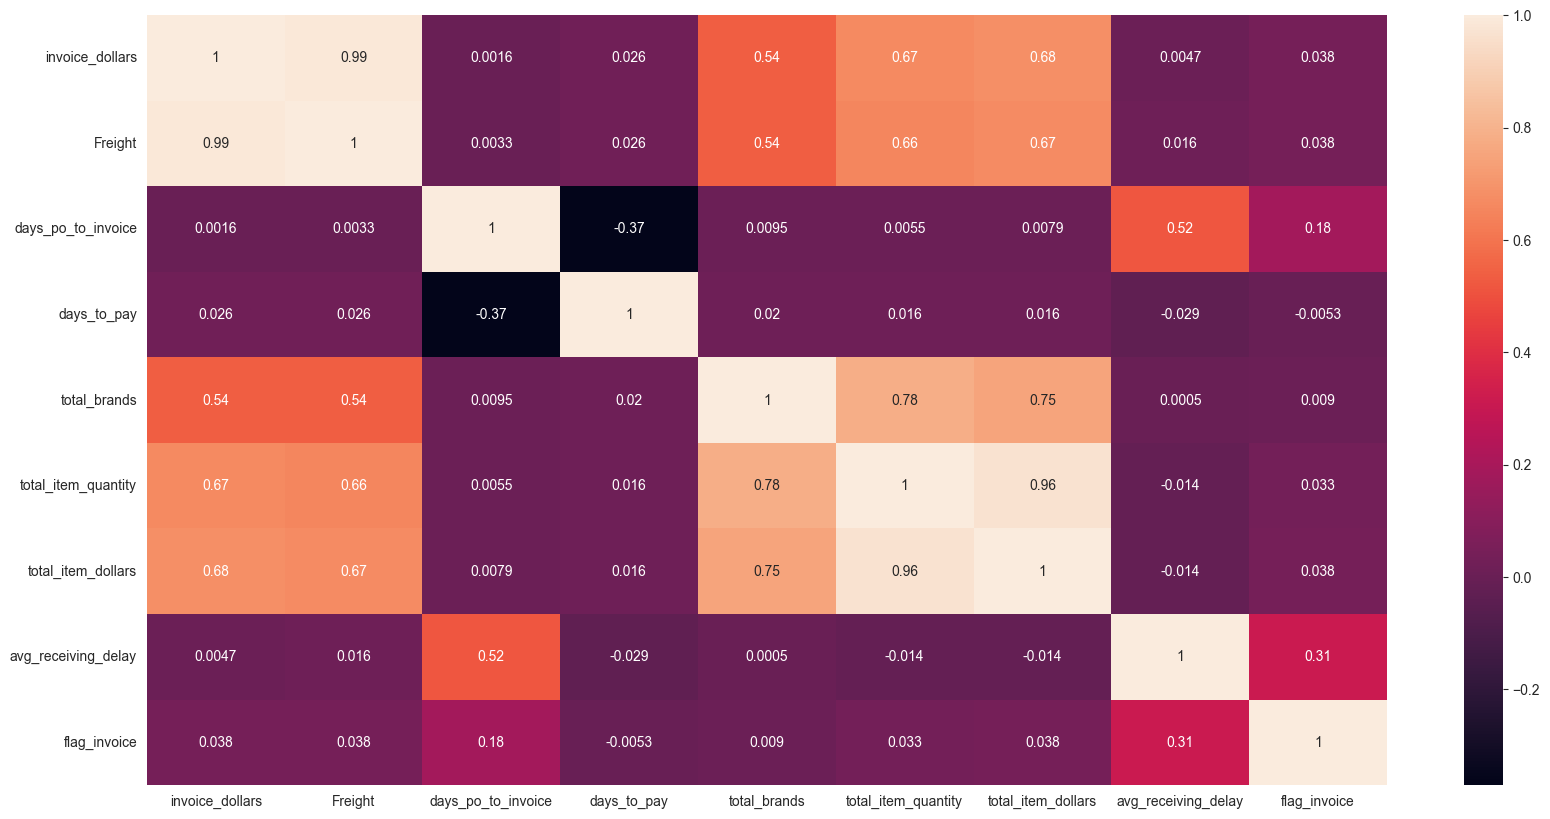

In [19]:
plt.figure(figsize=(20,10))
sns.heatmap(df.iloc[:,2:].corr(),annot =True)
plt.show()

**Do flag invoices metrics are different compared to normal invoices?**

Why this matters:
- Validates that the label reflects meaningful financial risk
- Confirms learnable signal exists before ML

In [20]:

flagged = df[df["flag_invoice"] == 1]
normal = df[df["flag_invoice"] == 0]

metrics = ['invoice_quantity', 'invoice_dollars', 'Freight',
       'days_po_to_invoice', 'days_to_pay', 'total_brands',
       'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay']

results = []
significant_features = []
non_significant_features = []

for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )
    
    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
        "metric": metric,
        "flagged_mean": flagged_mean.round(2),
        "normal_mean": normal_mean.round(2),
        "p_value": p_value.round(3)
    })
    else:
        non_significant_features.append(metric)

In [21]:
non_significant_features

['days_to_pay', 'total_brands']

In [22]:
pd.DataFrame(results)

,metric,flagged_mean,normal_mean,p_value
0,invoice_quantity,6728.28,5723.55,0.021
1,invoice_dollars,65600.61,54302.64,0.008
2,Freight,334.02,276.89,0.008
3,days_po_to_invoice,17.23,16.02,0.000
4,total_item_quantity,6728.28,5723.55,0.021
5,total_item_dollars,65600.61,54302.64,0.008
6,avg_receiving_delay,8.47,7.27,0.000


# Machine Learning Modeling

In [23]:
def evaluate_model(model, X_test, y_test, model_name):
    preds = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, preds)
    report = classification_report(y_test, preds)
    
    print(f"\n{model_name} Performance:")
    print(f"Accuracy  : {accuracy:.2f}")
    print(f"Classification Report : \n{report}")

In [24]:
X = df[['invoice_quantity','invoice_dollars','Freight','total_brands','total_item_quantity','days_po_to_invoice','total_item_dollars']]
y = df['flag_invoice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

model2 = DecisionTreeClassifier(random_state = 42)
model2.fit(X_train_scaled, y_train)

model3 = RandomForestClassifier(random_state = 42)
model3.fit(X_train_scaled, y_train)

evaluate_model(model1, X_test_scaled, y_test, 'Logistic Regression')
evaluate_model(model2, X_test_scaled, y_test, 'Decision Tree Classifier')
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')


Logistic Regression Performance:
Accuracy  : 0.66
Classification Report : 
              precision    recall  f1-score   support

           0       0.66      0.98      0.79       725
           1       0.56      0.06      0.11       384

    accuracy                           0.66      1109
   macro avg       0.61      0.52      0.45      1109
weighted avg       0.63      0.66      0.55      1109


Decision Tree Classifier Performance:
Accuracy  : 0.81
Classification Report : 
              precision    recall  f1-score   support

           0       0.85      0.86      0.86       725
           1       0.74      0.71      0.72       384

    accuracy                           0.81      1109
   macro avg       0.79      0.79      0.79      1109
weighted avg       0.81      0.81      0.81      1109


Random Forest Classifier Performance:
Accuracy  : 0.88
Classification Report : 
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       725

In [25]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model3.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
6,total_item_dollars,0.219493
4,total_item_quantity,0.176710
0,invoice_quantity,0.151379
1,invoice_dollars,0.151227
2,Freight,0.144806
3,total_brands,0.079205
5,days_po_to_invoice,0.077180


# Hyperparameter Tuning

In [26]:
X = df[['invoice_quantity','invoice_dollars','Freight','total_item_quantity','total_item_dollars']]
y = df['flag_invoice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [27]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100,200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion":['gini','entropy']
}
scorer = make_scorer(f1_score)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
evaluate_model(grid_search, X_test_scaled, y_test, 'Random Forest Classifier')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Random Forest Classifier Performance:
Accuracy  : 0.89
Classification Report : 
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       725
           1       0.96      0.71      0.82       384

    accuracy                           0.89      1109
   macro avg       0.91      0.85      0.87      1109
weighted avg       0.90      0.89      0.89      1109



Flagged invoices have higher mean values then the Normal invoices, and the difference is statistically significant.
This confirms that these features are primary driver of the review decision. This is a strong validation of the Business intuition.

Flagged invoices are associated with larger order size, higher financial exposure, greater operational complexity, and longer payment and receiving delays. They have significantly higher quantities, invoice values, freight costs, and number of brands, indicating that manual review is primarily driven by scale and complexity risk rather than isolated pricing anomalies. Additionally, longer payment and receiving delays suggest that flagged invoices are more likely to involve operational or reconciliation issues.

A p-value close to zero means the difference we observe is statistically very strong and unlikely to be random, so we can trust that this feature genuinely separates flagged and non-flagged invoices.